# Telco Churn - Boosted Models Strategy

This notebook explores stronger tabular models for churn prediction and compares them against logistic regression under the same leakage-free setup.

## Goals
- Keep stratified train/validation/test splits
- Avoid preprocessing leakage
- Train CatBoost and XGBoost with light hyperparameter search
- Tune classification threshold on validation only
- Compare with deployment-relevant metrics (ROC-AUC, PR-AUC, recall, precision, F1)


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import os
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


## Load, clean, encode, split

Uses the same feature cleaning approach as other notebooks, then performs a stratified 70/15/15 split.


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df.drop(columns=['customerID'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=15 / 85, random_state=SEED, stratify=y_tv
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print('Sizes train/val/test:', X_train.shape[0], X_val.shape[0], X_test.shape[0])
print('Churn rates train/val/test:', round(y_train.mean(), 4), round(y_val.mean(), 4), round(y_test.mean(), 4))


Sizes train/val/test: 4922 1055 1055
Churn rates train/val/test: 0.2659 0.2654 0.2654


## Utility functions


In [3]:
def threshold_max_f1(y_true, proba, n=199):
    ts = np.linspace(0.005, 0.995, n)
    best_t, best_f1 = 0.5, -1.0
    for t in ts:
        pred = (proba >= t).astype(int)
        f = f1_score(y_true, pred, zero_division=0)
        if f > best_f1:
            best_t, best_f1 = t, f
    return best_t, best_f1


def evaluate_model(name, y_val_arr, p_val, y_test_arr, p_test):
    t, val_f1 = threshold_max_f1(y_val_arr, p_val)
    y_pred = (p_test >= t).astype(int)

    return {
        'model': name,
        'threshold_from_val': t,
        'val_f1': val_f1,
        'roc_auc': roc_auc_score(y_test_arr, p_test),
        'pr_auc': average_precision_score(y_test_arr, p_test),
        'accuracy': accuracy_score(y_test_arr, y_pred),
        'precision': precision_score(y_test_arr, y_pred),
        'recall': recall_score(y_test_arr, y_pred),
        'f1': f1_score(y_test_arr, y_pred),
        'y_pred': y_pred,
        'p_test': p_test,
    }


## Logistic regression reference


In [4]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr.fit(X_train_s, y_train.to_numpy())
p_val_lr = lr.predict_proba(X_val_s)[:, 1]
p_test_lr = lr.predict_proba(X_test_s)[:, 1]

res_lr = evaluate_model('Logistic Regression', y_val.to_numpy(), p_val_lr, y_test.to_numpy(), p_test_lr)
res_lr


{'model': 'Logistic Regression',
 'threshold_from_val': np.float64(0.5650000000000001),
 'val_f1': 0.6463022508038585,
 'roc_auc': 0.8311797235023042,
 'pr_auc': 0.5910304247654579,
 'accuracy': 0.7469194312796209,
 'precision': 0.5160493827160494,
 'recall': 0.7464285714285714,
 'f1': 0.6102189781021898,
 'y_pred': array([1, 0, 1, ..., 0, 1, 1], shape=(1055,)),
 'p_test': array([0.8389838 , 0.01554433, 0.78363038, ..., 0.06105271, 0.86145094,
        0.86715967], shape=(1055,))}

## CatBoost search


In [5]:
cat_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [3, 7],
    'iterations': [300, 500],
}

best_cat = None
best_cat_ap = -1
best_cat_params = None

for params in ParameterGrid(cat_grid):
    cat = CatBoostClassifier(
        random_seed=SEED,
        loss_function='Logloss',
        eval_metric='AUC',
        verbose=False,
        **params
    )
    cat.fit(X_train, y_train)
    p_val = cat.predict_proba(X_val)[:, 1]
    ap = average_precision_score(y_val, p_val)

    if ap > best_cat_ap:
        best_cat_ap = ap
        best_cat = cat
        best_cat_params = params

print('Best CatBoost params:', best_cat_params)
print('Best CatBoost val PR-AUC:', round(best_cat_ap, 4))

p_val_cat = best_cat.predict_proba(X_val)[:, 1]
p_test_cat = best_cat.predict_proba(X_test)[:, 1]
res_cat = evaluate_model('CatBoost', y_val.to_numpy(), p_val_cat, y_test.to_numpy(), p_test_cat)
res_cat


Best CatBoost params: {'depth': 4, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Best CatBoost val PR-AUC: 0.6748


{'model': 'CatBoost',
 'threshold_from_val': np.float64(0.31),
 'val_f1': 0.6430868167202572,
 'roc_auc': 0.8406612903225807,
 'pr_auc': 0.6417254271197609,
 'accuracy': 0.7545023696682465,
 'precision': 0.5256723716381418,
 'recall': 0.7678571428571429,
 'f1': 0.6240928882438317,
 'y_pred': array([1, 0, 1, ..., 0, 1, 1], shape=(1055,)),
 'p_test': array([0.62708186, 0.01440554, 0.35074777, ..., 0.04322228, 0.68911823,
        0.62968075], shape=(1055,))}

## XGBoost search


In [6]:
xgb_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'n_estimators': [300, 500],
}

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = float(neg / pos)

best_xgb = None
best_xgb_ap = -1
best_xgb_params = None

for params in ParameterGrid(xgb_grid):
    xgb = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        **params
    )
    xgb.fit(X_train_s, y_train.to_numpy())
    p_val = xgb.predict_proba(X_val_s)[:, 1]
    ap = average_precision_score(y_val, p_val)

    if ap > best_xgb_ap:
        best_xgb_ap = ap
        best_xgb = xgb
        best_xgb_params = params

print('Best XGBoost params:', best_xgb_params)
print('Best XGBoost val PR-AUC:', round(best_xgb_ap, 4))

p_val_xgb = best_xgb.predict_proba(X_val_s)[:, 1]
p_test_xgb = best_xgb.predict_proba(X_test_s)[:, 1]
res_xgb = evaluate_model('XGBoost', y_val.to_numpy(), p_val_xgb, y_test.to_numpy(), p_test_xgb)
res_xgb


Best XGBoost params: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best XGBoost val PR-AUC: 0.6636


{'model': 'XGBoost',
 'threshold_from_val': np.float64(0.5800000000000001),
 'val_f1': 0.6373983739837399,
 'roc_auc': 0.8383018433179723,
 'pr_auc': 0.6426712492266113,
 'accuracy': 0.7516587677725118,
 'precision': 0.5231958762886598,
 'recall': 0.725,
 'f1': 0.6077844311377245,
 'y_pred': array([1, 0, 1, ..., 0, 1, 1], shape=(1055,)),
 'p_test': array([0.8348768 , 0.02607764, 0.65621454, ..., 0.1418422 , 0.8593439 ,
        0.83495355], shape=(1055,), dtype=float32)}

## Final comparison


In [7]:
results = [res_lr, res_cat, res_xgb]
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred', 'p_test']} for r in results
]).sort_values(['pr_auc', 'f1'], ascending=False).reset_index(drop=True)
comparison


,model,threshold_from_val,val_f1,roc_auc,pr_auc,accuracy,precision,recall,f1
0,XGBoost,0.580,0.637398,0.838302,0.642671,0.751659,0.523196,0.725000,0.607784
1,CatBoost,0.310,0.643087,0.840661,0.641725,0.754502,0.525672,0.767857,0.624093
2,Logistic Regression,0.565,0.646302,0.831180,0.591030,0.746919,0.516049,0.746429,0.610219


In [ ]:
comparison.to_csv(f"{FIG_DIR}/boosted_metrics.csv", index=False)
print(f"Saved -> {FIG_DIR}/boosted_metrics.csv")
comparison

## Confusion matrices


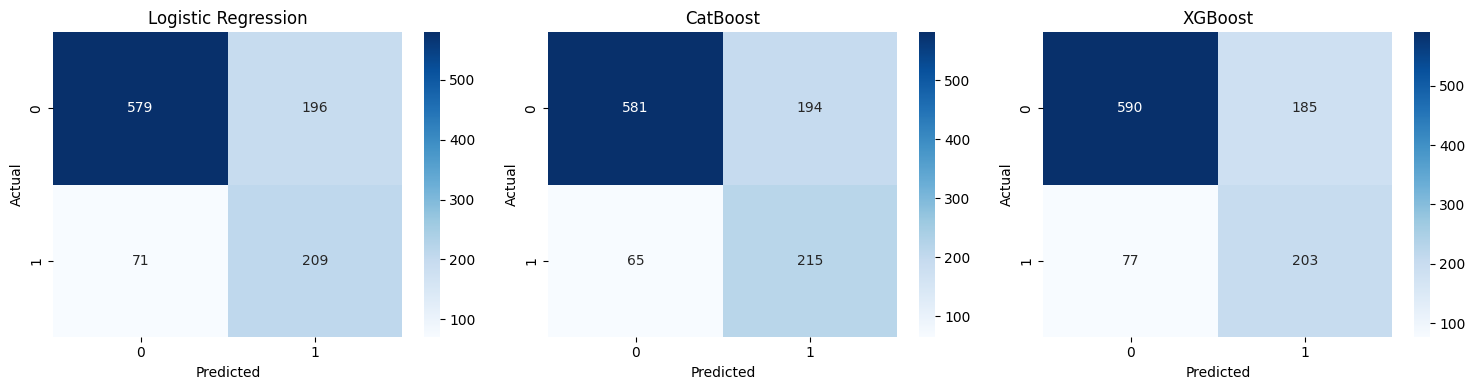

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test.to_numpy(), r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(r['model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/boosted_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## ROC and PR curves


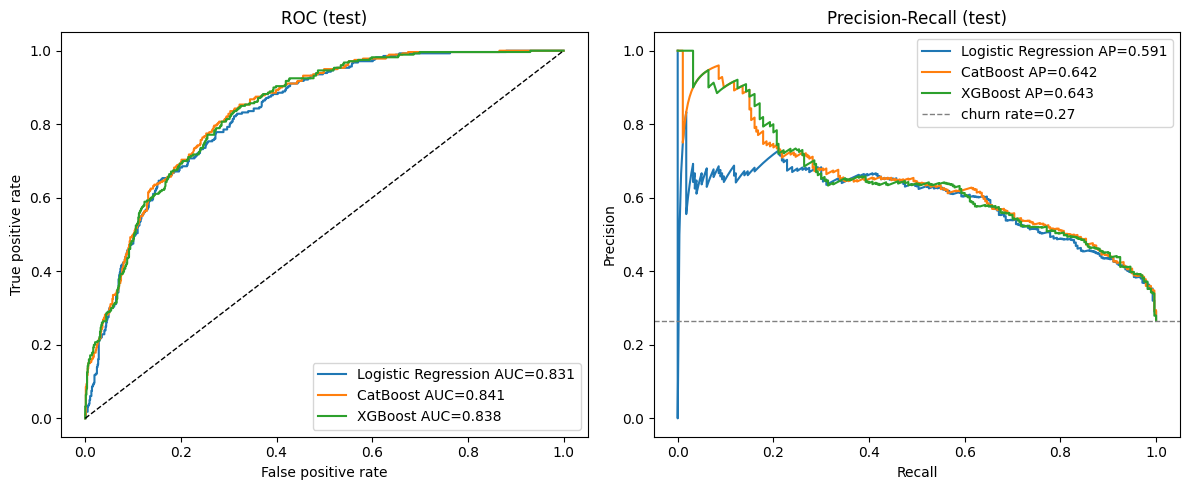

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for r in results:
    fpr, tpr, _ = roc_curve(y_test.to_numpy(), r['p_test'])
    axes[0].plot(fpr, tpr, label=f"{r['model']} AUC={r['roc_auc']:.3f}")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC (test)')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend()

for r in results:
    prec, rec, _ = precision_recall_curve(y_test.to_numpy(), r['p_test'])
    axes[1].plot(rec, prec, label=f"{r['model']} AP={r['pr_auc']:.3f}")

baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', lw=1, label=f"churn rate={baseline:.2f}")
axes[1].set_title('Precision-Recall (test)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/boosted_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Interpreting outcomes

- If **PR-AUC** and recall improve with acceptable precision loss, boosted trees are helping retention targeting.
- If gains are marginal, logistic regression may remain preferable due to simpler deployment and explainability.
- Keep `scaler`, model object, and validation-tuned threshold together for reproducible inference.


In [10]:
# One-line recommendation for symposium/deployment discussion
# Set this to one of: 'f1', 'recall', 'pr_auc', 'roc_auc', 'precision', 'accuracy'
priority_metric = 'pr_auc'

best_row = comparison.sort_values(priority_metric, ascending=False).iloc[0]
print(
    f"Recommended model by {priority_metric}: {best_row['model']} "
    f"(threshold={best_row['threshold_from_val']:.3f}, "
    f"PR-AUC={best_row['pr_auc']:.3f}, Recall={best_row['recall']:.3f}, F1={best_row['f1']:.3f})"
)

Recommended model by pr_auc: XGBoost (threshold=0.580, PR-AUC=0.643, Recall=0.725, F1=0.608)


## Feature importance — which features drive churn?

In [ ]:
# Feature importance for the best CatBoost model
# Uses CatBoost's built-in importance (fast). If `shap` is installed,
# also produce a SHAP summary bar plot for the same model.
import numpy as np

cat_importance = pd.Series(
    best_cat.get_feature_importance(),
    index=X_train.columns,
).sort_values(ascending=True)

top = cat_importance.tail(15)
fig, ax = plt.subplots(figsize=(7, 6))
top.plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("CatBoost feature importance")
ax.set_title("Top 15 churn drivers — CatBoost")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/feature_importance_catboost.png", dpi=150, bbox_inches="tight")
plt.show()

cat_importance.sort_values(ascending=False).to_csv(
    f"{FIG_DIR}/feature_importance_catboost.csv", header=["importance"]
)
print(f"Saved -> {FIG_DIR}/feature_importance_catboost.csv")

try:
    import shap
    explainer = shap.TreeExplainer(best_cat)
    sv = explainer.shap_values(X_val)
    shap.summary_plot(sv, X_val, plot_type="bar", show=False, max_display=15)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/shap_summary_catboost.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved SHAP summary plot.")
except Exception as e:
    print(f"(Optional) Skipped SHAP plot: {e}")


## Unified comparison across all 4 models

Combines `baseline_metrics.csv` + `nn_metrics.csv` + `boosted_metrics.csv`.
Run the other two notebooks first; rerun this cell.

In [ ]:
# Combine baseline + neural network + boosted metrics into a single
# poster-ready table.
import os
files = [
    f"{FIG_DIR}/baseline_metrics.csv",
    f"{FIG_DIR}/nn_metrics.csv",
    f"{FIG_DIR}/boosted_metrics.csv",
]
parts = []
for f in files:
    if os.path.exists(f):
        parts.append(pd.read_csv(f))
    else:
        print(f"[skip] missing: {f}  (run that notebook first)")

if parts:
    all_df = pd.concat(parts, ignore_index=True)
    cols = ["model", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
    keep = [c for c in cols if c in all_df.columns]
    all_df = all_df[keep + [c for c in all_df.columns if c not in keep]]
    all_df = all_df.drop_duplicates(subset=["model"], keep="last").reset_index(drop=True)
    all_df = all_df.sort_values("f1", ascending=False).reset_index(drop=True)
    all_df.to_csv(f"{FIG_DIR}/all_models_comparison.csv", index=False)
    print(f"Saved -> {FIG_DIR}/all_models_comparison.csv")
    display_cols = [c for c in ["model","accuracy","precision","recall","f1","roc_auc","pr_auc"] if c in all_df.columns]
    print(all_df[display_cols].to_string(index=False))
